## EDA del dataset Framingham

Objetivo

El objetivo de este análisis exploratorio es estudiar qué características de salud y estilo de vida están relacionadas con la aparición de enfermedad coronaria a 10 años (`TenYearCHD`).

Tenemos variables demográficas, hábitos de tabaco, antecedentes médicos y medidas clínicas como colesterol, presión arterial, IMC, frecuencia cardíaca y glucosa.

## Preguntas

- ¿Qué proporción de pacientes desarrolla enfermedad coronaria a 10 años?
- ¿Hay diferencias relevantes según edad, sexo o tabaquismo?
- ¿Qué variables clínicas parecen asociarse más con `TenYearCHD`?
- ¿Existen valores nulos, atípicos o inconsistencias que debamos tratar?


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="Set2")

df = pd.read_csv("data/framingham.csv", na_values="NA")

df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Duplicados: {df.duplicated().sum()}")

display(df.dtypes.to_frame("tipo_dato"))

resumen_nulos = (
    df.isna()
    .sum()
    .to_frame("nulos")
    .assign(pct_nulos=lambda x: round(x["nulos"] / len(df) * 100, 2))
    .sort_values("pct_nulos", ascending=False)
)

display(resumen_nulos)


Filas: 4240
Columnas: 16
Duplicados: 0


,tipo_dato
male,int64
age,int64
education,float64
currentSmoker,int64
cigsPerDay,float64
BPMeds,float64
prevalentStroke,int64
prevalentHyp,int64
diabetes,int64
totChol,float64


,nulos,pct_nulos
glucose,388,9.15
education,105,2.48
BPMeds,53,1.25
totChol,50,1.18
cigsPerDay,29,0.68
BMI,19,0.45
heartRate,1,0.02
male,0,0.00
age,0,0.00
currentSmoker,0,0.00


## Primera inspección del dataset

El dataset contiene 4240 registros y 16 variables. No hay filas duplicadas.

La mayoría de variables están completas, aunque existen valores nulos en algunas columnas clínicas y sociodemográficas. La variable con más valores ausentes es `glucose`, con algo más del 9% de registros sin información. El resto de columnas con nulos presentan porcentajes bajos.

De momento no voy a eliminar ni imputar valores ausentes. Primero voy a analizar la distribución de la variable objetivo y de las principales variables explicativas y luego veo que tratamiento usar.

,conteo,porcentaje
TenYearCHD,,
0,3596,84.81
1,644,15.19


/var/folders/2q/hp4lnzhj29g5vjty0v59zgmh0000gn/T/ipykernel_38137/3622598928.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No desarrolla CHD", "Desarrolla CHD"])


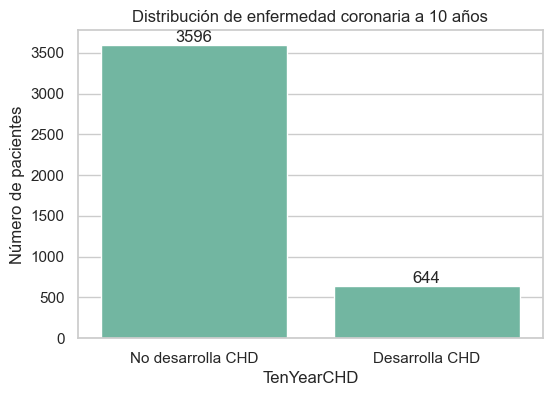

In [5]:
conteo_chd = df["TenYearCHD"].value_counts().sort_index()
porcentaje_chd = df["TenYearCHD"].value_counts(normalize=True).sort_index() * 100

resumen_chd = pd.DataFrame({
    "conteo": conteo_chd,
    "porcentaje": porcentaje_chd.round(2)
})

display(resumen_chd)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="TenYearCHD")

ax.set_title("Distribución de enfermedad coronaria a 10 años")
ax.set_xlabel("TenYearCHD")
ax.set_ylabel("Número de pacientes")
ax.set_xticklabels(["No desarrolla CHD", "Desarrolla CHD"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Distribución de la variable objetivo

La variable objetivo `TenYearCHD` indica si el paciente desarrolló enfermedad coronaria en un periodo de 10 años.

Veo un claro desbalance entre clases: aproximadamente el 85% de los pacientes no desarrolló enfermedad coronaria, mientras que mas o menos el 15% sí la desarrolló.

In [6]:
variables_numericas = [
    "age", "cigsPerDay", "totChol", "sysBP", "diaBP",
    "BMI", "heartRate", "glucose"
]

df[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0
sysBP,4240.0,132.354599,22.033300,83.50,117.00,128.0,144.00,295.0
diaBP,4240.0,82.897759,11.910394,48.00,75.00,82.0,90.00,142.5
BMI,4221.0,25.800801,4.079840,15.54,23.07,25.4,28.04,56.8
heartRate,4239.0,75.878981,12.025348,44.00,68.00,75.0,83.00,143.0
glucose,3852.0,81.963655,23.954335,40.00,71.00,78.0,87.00,394.0


## Resumen estadístico de variables numéricas

La edad de los pacientes se sitúa entre 32 y 70 años, con una media cerca de los 50 años. Por lo tanto la muestra esta formada principalmente por adultos de mediana edad y personas mayores.

En cuanto al consumo de tabaco, la mediana de `cigsPerDay` es 0, ya que mas de la mitad no fuma. Pero el máximo alcanza 70 cigarrillos diarios, existiendo fumadores con consumos muy elevados.

Las variables clínicas muestran rangos amplios. El colesterol total (`totChol`) tiene una media aproximada de 237, pero alcanza valores máximos muy altos, como 696. La presión arterial sistólica (`sysBP`) también presenta valores extremos, llegando hasta 295.

El IMC medio es de aproximadamente 25.8, situado en el rango de sobrepeso. También aparecen valores altos de IMC, con un máximo superior a 56.

La glucosa tiene una mediana de 78, pero presenta valores máximos muy elevados, hasta 394. Esto puede indicar pacientes con alteraciones importantes de glucosa o posibles valores extremos que luego voy a revisar.

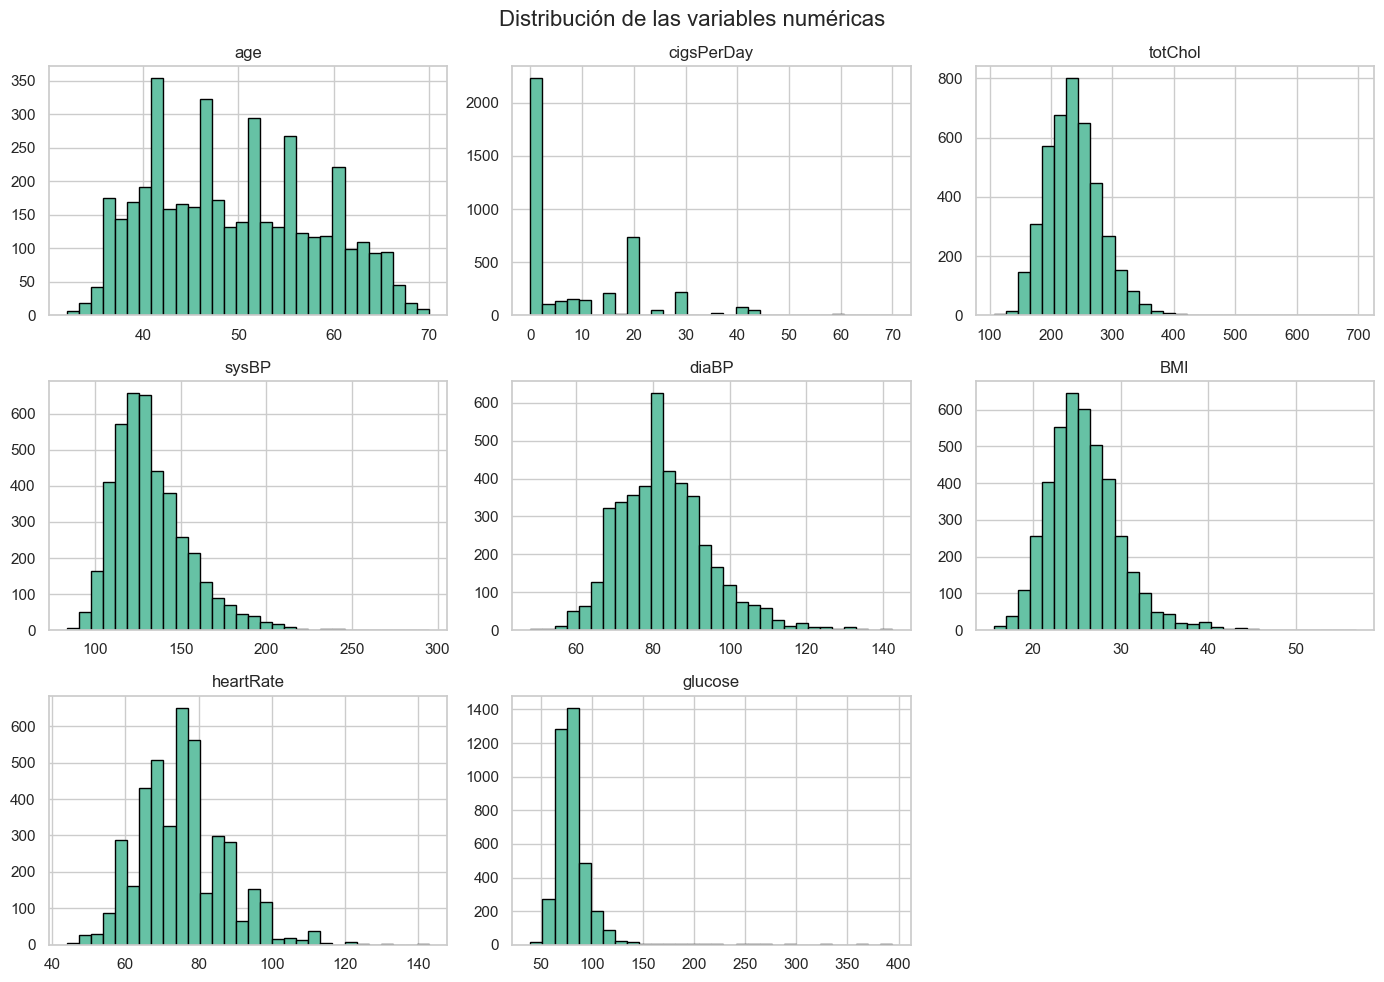

In [7]:
df[variables_numericas].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribución de las variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()


## Distribución de las variables numéricas

Las variables numéricas muestran comportamientos distintos.

La edad presenta una distribución repartida entre adultos de mediana edad y mayores, sin valores extremos a simple vista.

`cigsPerDay` tiene una concentración muy alta en 0, debido a la presencia de muchos pacientes no fumadores. Por eso, hay que analizar el consumo de cigarrillos separando únicamente a los fumadores actuales.

Las variables clínicas como `totChol`, `sysBP`, `BMI` y `glucose` presentan asimetría hacia la derecha, indicando que la mayoría de pacientes se concentra en valores moderados, aunque existen registros con valores muy elevados.

Estos valores extremos no los voy a eliminar automáticamente, ya que pueden representar a pacientes con condiciones médicas relevantes. Después voy a revisar con boxplots para detectar posibles outliers.

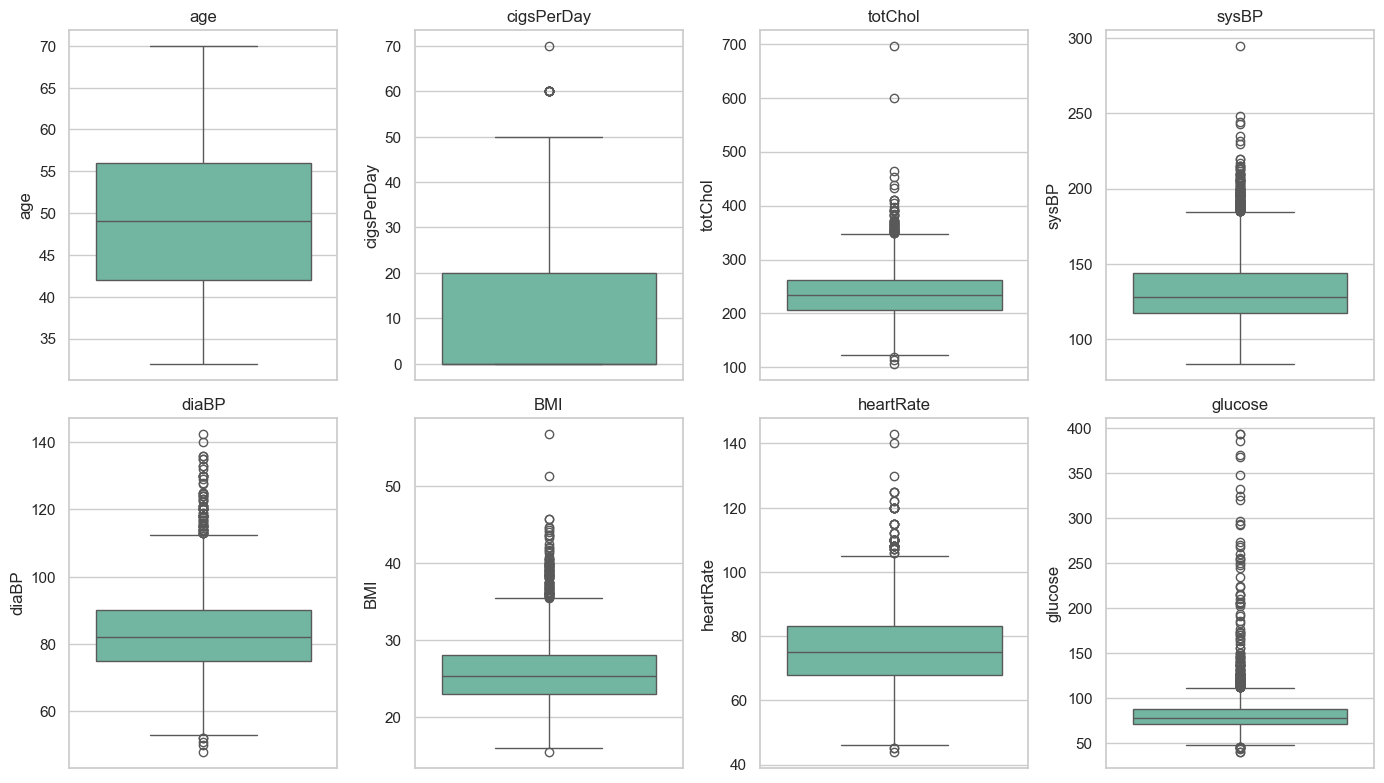

In [8]:
plt.figure(figsize=(14, 8))

for i, col in enumerate(variables_numericas, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Valores extremos y outliers

Para poder ver claramente valores extremos y outliers he utilizado gráficos bloxplot. 

En la edad no veo ningun, pero en el resto vemos claramente valores atípicos. 

De momento no elimino nada ya que como antes he dicho pueden pertenecer a pacientes con problemas de salud relevantes.